In [1]:
!python3 -m pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv('/Users/arhamadeem/Desktop/minecraft internship/housing.csv')

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Users/arhamadeem/Desktop/minecraft internship/housing.csv'

In [4]:
df = pd.read_csv('housing.csv')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [6]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [7]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [8]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

In [9]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [10]:
X = df.drop('median_house_value', axis=1)

y = df['median_house_value']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [13]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [14]:
print("R2 Score:", r2_score(y_test, lr_pred))

print("MAE:", mean_absolute_error(y_test, lr_pred))

print("MSE:", mean_squared_error(y_test, lr_pred))

R2 Score: 0.6254240620553605
MAE: 50670.73824097191
MSE: 4908476721.156617


In [15]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train_scaled, y_train)

dt_pred = dt.predict(X_test_scaled)

In [16]:
print("R2 Score:", r2_score(y_test, dt_pred))

print("MAE:", mean_absolute_error(y_test, dt_pred))

print("MSE:", mean_squared_error(y_test, dt_pred))

R2 Score: 0.6294725691776935
MAE: 44120.67999031008
MSE: 4855424720.340843


In [17]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

In [18]:
print("R2 Score:", r2_score(y_test, rf_pred))

print("MAE:", mean_absolute_error(y_test, rf_pred))

print("MSE:", mean_squared_error(y_test, rf_pred))

R2 Score: 0.8167090228826115
MAE: 31631.0186749031
MSE: 2401861420.4517317


In [19]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred)
    ],
    
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, rf_pred)
    ]
})

results

,Model,R2 Score,MAE
0,Linear Regression,0.625424,50670.738241
1,Decision Tree,0.629473,44120.679990
2,Random Forest,0.816709,31631.018675


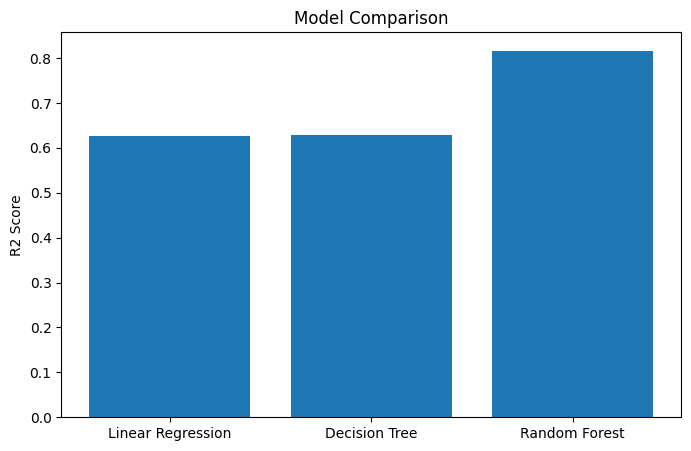

In [20]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['R2 Score'])

plt.title('Model Comparison')

plt.ylabel('R2 Score')

plt.show()

In [21]:
print("""
Conclusion:

Different machine learning models were trained and compared
for house price prediction. After preprocessing and feature
scaling, Random Forest Regressor achieved the best performance
with the highest R2 Score. Therefore, it was selected as the
final model.
""")


Conclusion:

Different machine learning models were trained and compared
for house price prediction. After preprocessing and feature
scaling, Random Forest Regressor achieved the best performance
with the highest R2 Score. Therefore, it was selected as the
final model.

